In [53]:
from IPython.display import Markdown
import torch
import torch.nn.functional as F
import string
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## data

In [2]:
with open("../data/usnames.txt", "r") as f:
    names = f.readlines()
names = [n.strip() for n in names]

In [3]:
names[:3]

['emma', 'olivia', 'ava']

## tokenize

In [4]:
tok2idx = {c: i for i, c in enumerate('.' + string.ascii_lowercase)}
idx2tok = {i: c for c, i in tok2idx.items()}

## modeling

In [136]:
emb_sz = 3
ctx_len = 2
lr = 0.1

In [137]:
X, Y = [], []

for name in names:
    ctx = ['.'] * ctx_len
    for c in name + '.':
        x = [tok2idx[c] for c in ctx]
        y = tok2idx[c]
        ctx.append(c); ctx.pop(0)
        X.append(x); Y.append(y)

X = torch.tensor(X)
Y = torch.tensor(Y)

In [138]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 100, generator=g)
b1 = torch.randn(100, generator=g)

# output layer
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

number of parameters = 3508


In [139]:
for p in params: p.requires_grad = True

In [149]:
for i in range(1000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, X.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[X[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])
    
    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    for p in params:
        p.data += -lr*p.grad
    
print(loss.item())

2.4955496788024902


In [150]:
# calculating the total loss

X_emb = word_embeddings[X]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4928, grad_fn=<NllLossBackward0>)

### figuring out a good learning rate

In [151]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [156]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 100, generator=g)
b1 = torch.randn(100, generator=g)

# output layer
W2 = torch.randn(100, 27, generator=g)
b2 = torch.randn(27, generator=g)

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

for p in params: p.requires_grad = True

number of parameters = 3508


In [157]:
losses = []
for i in range(1000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, X.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[X[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ixs])
    
    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    for p in params:
        p.data += -lrs[i]*p.grad

    # track
    losses.append(loss.item())
    
print(loss.item())

6.881778240203857


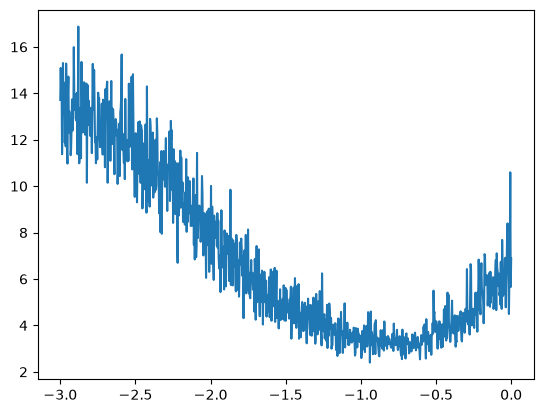

In [159]:
plt.plot(lre, losses);

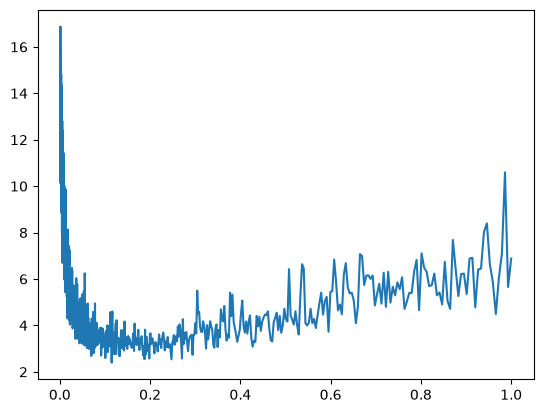

In [160]:
plt.plot(lrs, losses);

### making data splits

In [164]:
def build_dataset(names, ctx_len=ctx_len):
    X, Y = [], []

    for name in names:
        ctx = ['.'] * ctx_len
        for c in name + '.':
            x = [tok2idx[c] for c in ctx]
            y = tok2idx[c]
            ctx.append(c); ctx.pop(0)
            X.append(x); Y.append(y)
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr, Ytr = build_dataset(names[:n1])
Xdev, Ydev = build_dataset(names[n1:n2])
Xte, Yte = build_dataset(names[n2:])

In [166]:
Xtr.shape, Xdev.shape, Xte.shape

(torch.Size([182481, 2]), torch.Size([22880, 2]), torch.Size([22785, 2]))

### modeling contd.

In [188]:
emb_sz = 3
ctx_len = 2
lr = 0.1

In [189]:
g = torch.Generator().manual_seed(2147483647)

word_embeddings = torch.randn((27, emb_sz), dtype=torch.float32, generator=g)

# 1st hidden layer with 100 neurons
W1 = torch.randn(emb_sz*ctx_len, 300, generator=g)
b1 = torch.randn(300, generator=g)

# output layer
W2 = torch.randn(300, 27, generator=g)
b2 = torch.randn(27, generator=g)

params = [word_embeddings, W1, b1, W2, b2]

print(f"number of parameters = {sum([p.nelement() for p in params])}")

for p in params: p.requires_grad = True

number of parameters = 10308


In [190]:
steps = []
losses = []
for i in range(10000):
    # lets perform updates in minibatch to make the forward and backward pass more effective
    ixs = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    X_emb = word_embeddings[Xtr[ixs]]
    h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ixs])
    
    # backward pass
    for p in params:
        p.grad = None
    loss.backward()
    # update weights
    for p in params:
        p.data += -lr*p.grad

    # track
    steps.append(i)
    losses.append(loss.item())
    

    
print(loss.item())

2.760138511657715


In [191]:
# calculating the loss on full training set

X_emb = word_embeddings[Xtr]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.7051, grad_fn=<NllLossBackward0>)

In [192]:
# calculating the loss on validation set

X_emb = word_embeddings[Xdev]
h = torch.tanh(X_emb.view(-1, emb_sz*ctx_len) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.7161, grad_fn=<NllLossBackward0>)